# 10 · SVM & K-Nearest Neighbors (KNN)

**Difficulty:** Intermediate | **Time:** ~2.5 hours

## Table of Contents
1. K-Nearest Neighbors — Theory & Intuition
2. KNN for Classification
3. KNN for Regression
4. Choosing K — The Elbow Method
5. Support Vector Machines — Theory
6. SVM Classification (Linear & RBF Kernel)
7. Real-World: Handwritten Digit Recognition

## 1. KNN — Theory

**Idea:** To predict a new point, find the K nearest neighbors in the training data and take a majority vote.

**Distance metric:** Usually Euclidean:
$$d(a,b) = \sqrt{\sum_i (a_i - b_i)^2}$$

**Key insight:** KNN is a *lazy learner* — it memorizes training data and computes at prediction time.

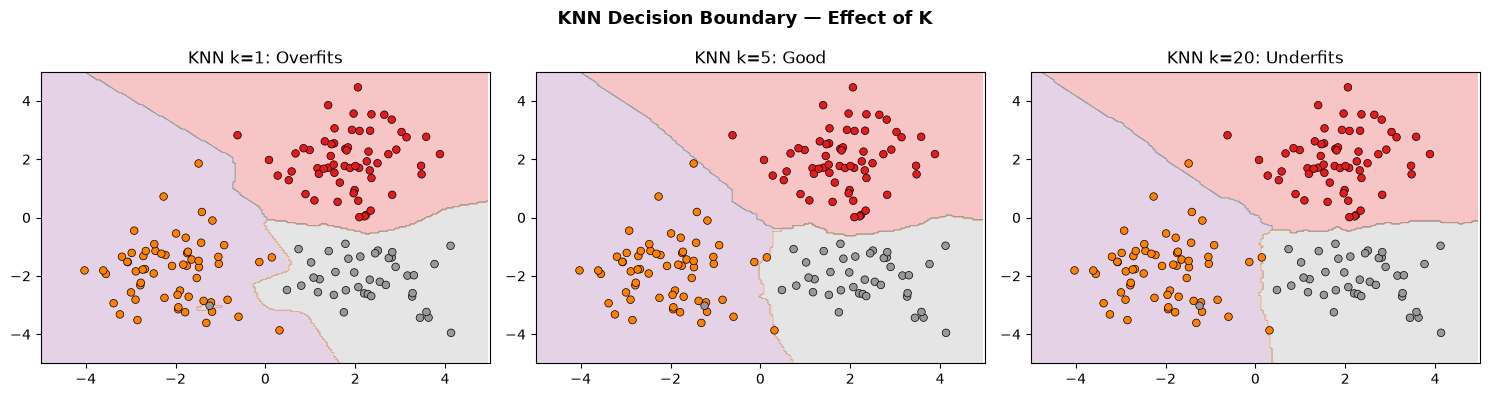

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_digits
import warnings
warnings.filterwarnings('ignore')

# Visualize KNN decision boundary
np.random.seed(42)
X_knn = np.r_[np.random.randn(60, 2) + [2, 2],
               np.random.randn(60, 2) + [-2, -2],
               np.random.randn(40, 2) + [2, -2]]
y_knn = np.array([0]*60 + [1]*60 + [2]*40)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [1, 5, 20]):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_knn, y_knn)
    
    h = 0.05
    xx, yy = np.meshgrid(np.arange(-5,5,h), np.arange(-5,5,h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='Set1')
    scatter = ax.scatter(X_knn[:,0], X_knn[:,1], c=y_knn, cmap='Set1', 
                          s=30, edgecolors='black', linewidths=0.5)
    ax.set_title(f"KNN k={k}: {'Overfits' if k==1 else 'Good' if k==5 else 'Underfits'}")
    ax.set_xlim(-5,5); ax.set_ylim(-5,5)

plt.suptitle("KNN Decision Boundary — Effect of K", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/knn_boundary.png", dpi=100)
plt.show()

## 2. Choosing the Right K

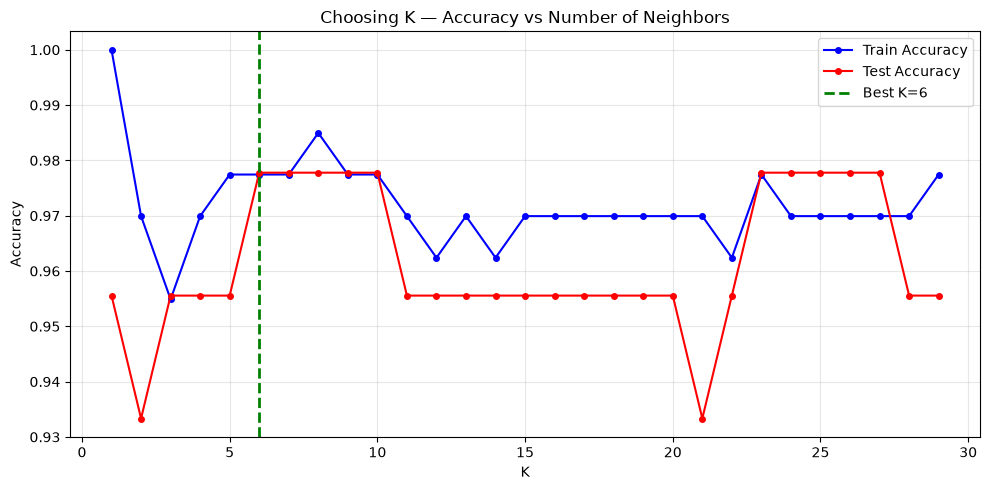

Best K=6 → Test Accuracy: 97.78%


In [2]:
from sklearn.datasets import load_wine

wine = load_wine()
X_w, y_w = wine.data, wine.target
X_tr, X_te, y_tr, y_te = train_test_split(X_w, y_w, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

train_scores, test_scores = [], []
k_range = range(1, 30)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_s, y_tr)
    train_scores.append(knn.score(X_tr_s, y_tr))
    test_scores.append(knn.score(X_te_s, y_te))

best_k = k_range[np.argmax(test_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, train_scores, 'b-o', ms=4, label='Train Accuracy')
ax.plot(k_range, test_scores,  'r-o', ms=4, label='Test Accuracy')
ax.axvline(best_k, color='green', linestyle='--', linewidth=2, label=f'Best K={best_k}')
ax.set_xlabel("K"); ax.set_ylabel("Accuracy")
ax.set_title("Choosing K — Accuracy vs Number of Neighbors")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/knn_k_selection.png", dpi=100)
plt.show()
print(f"Best K={best_k} → Test Accuracy: {max(test_scores):.2%}")

## 3. KNN Regression — Predict Continuous Values

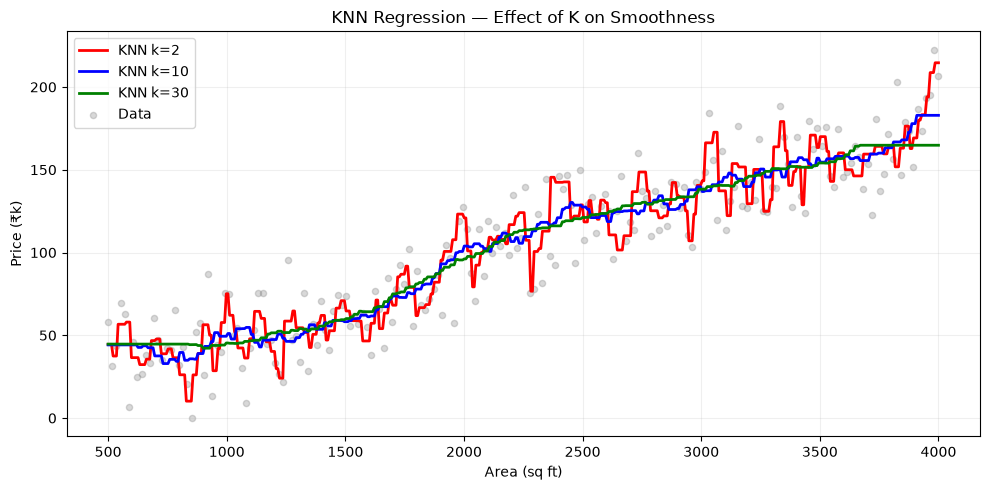

In [3]:
# House price prediction with KNN
np.random.seed(0)
area   = np.linspace(500, 4000, 200)
price  = (area * 45 + np.random.normal(0, 20000, 200)).clip(0)

X_r = area.reshape(-1, 1)
y_r = price

X_rtr, X_rte, y_rtr, y_rte = train_test_split(X_r, y_r, test_size=0.2, random_state=0)
sc2 = StandardScaler()
X_rtr_s = sc2.fit_transform(X_rtr)
X_rte_s = sc2.transform(X_rte)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['red','blue','green']
for k, color in zip([2, 10, 30], colors):
    knn_r = KNeighborsRegressor(n_neighbors=k)
    knn_r.fit(X_rtr_s, y_rtr)
    x_plot = np.linspace(500, 4000, 500).reshape(-1,1)
    y_plot = knn_r.predict(sc2.transform(x_plot))
    ax.plot(x_plot, y_plot/1000, color=color, linewidth=2, label=f'KNN k={k}')

ax.scatter(area, price/1000, alpha=0.3, s=20, color='gray', label='Data')
ax.set_xlabel("Area (sq ft)"); ax.set_ylabel("Price (₹k)")
ax.set_title("KNN Regression — Effect of K on Smoothness")
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("/tmp/knn_regression.png", dpi=100)
plt.show()

## 4. Support Vector Machines — Theory

**Goal:** Find the **maximum-margin hyperplane** that separates classes.

```
  Class 0 ●       ←margin→    ◆ Class 1
  ●   ●           ────────         ◆  ◆
      ●     ─────  margin  ─────  ◆
  ●           ────────           ◆
                  Support Vectors (on the boundary)
```

**Kernel Trick:** For non-linearly separable data, map to higher dimensions:
- Linear: works when data is linearly separable
- RBF (Radial Basis Function): most powerful, handles curves

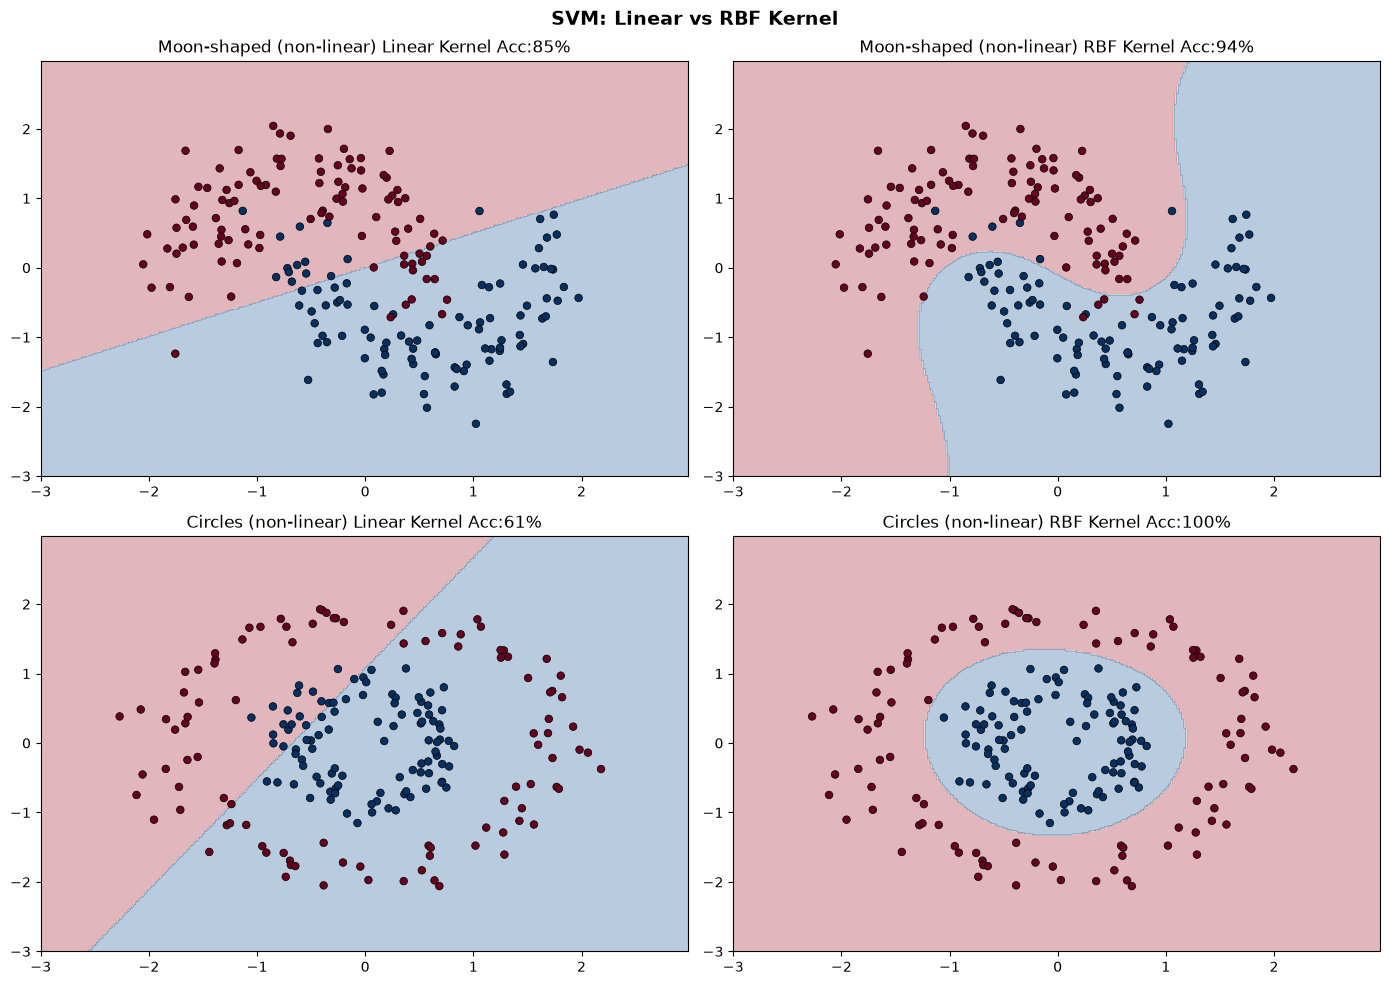

In [4]:
# Visualize linear vs RBF kernel
from sklearn.datasets import make_moons, make_circles

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets = [
    (make_moons(n_samples=200, noise=0.2, random_state=0), 'Moon-shaped (non-linear)'),
    (make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=0), 'Circles (non-linear)')
]

for row, (dataset, ds_name) in enumerate(datasets):
    X_d, y_d = dataset
    sc_d = StandardScaler()
    X_ds = sc_d.fit_transform(X_d)
    
    for col, (kernel, title) in enumerate([('linear','Linear Kernel'), ('rbf','RBF Kernel')]):
        svm = SVC(kernel=kernel, C=1.0)
        svm.fit(X_ds, y_d)
        
        h = 0.02
        xx, yy = np.meshgrid(np.arange(-3,3,h), np.arange(-3,3,h))
        Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        
        axes[row,col].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
        axes[row,col].scatter(X_ds[:,0], X_ds[:,1], c=y_d, cmap='RdBu', 
                               s=30, edgecolors='black', linewidths=0.5)
        acc = svm.score(X_ds, y_d)
        axes[row,col].set_title(f"{ds_name} {title} Acc:{acc:.0%}")

plt.suptitle("SVM: Linear vs RBF Kernel", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/svm_kernels.png", dpi=100)
plt.show()

## 5. The C Parameter — Regularization in SVM

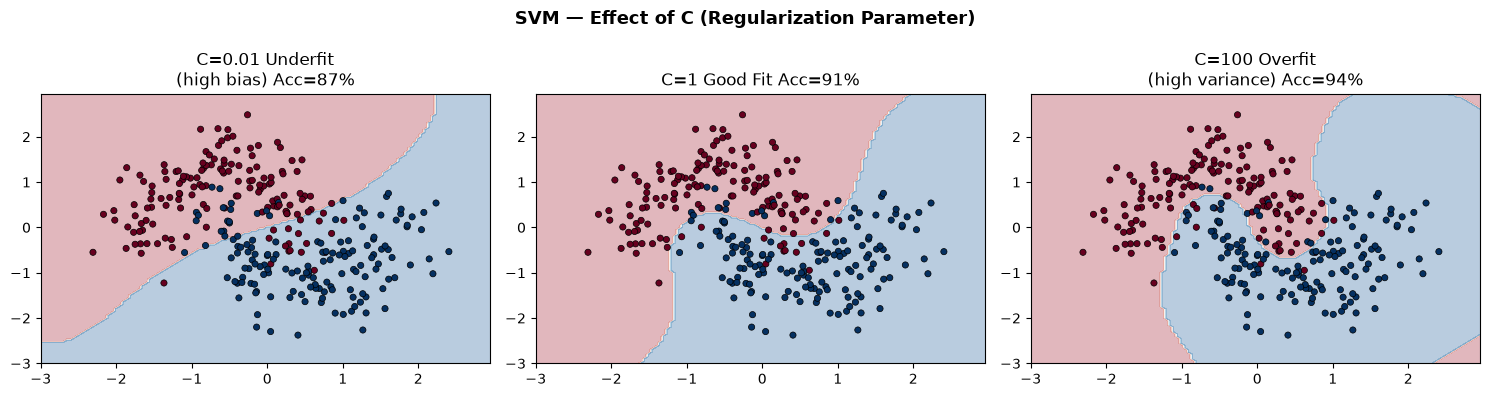

In [5]:
from sklearn.datasets import make_moons

X_m, y_m = make_moons(n_samples=300, noise=0.25, random_state=42)
sc_m = StandardScaler()
X_ms = sc_m.fit_transform(X_m)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
C_values = [0.01, 1, 100]
descriptions = ["Underfit\n(high bias)", "Good Fit", "Overfit\n(high variance)"]

for ax, C, desc in zip(axes, C_values, descriptions):
    svm = SVC(kernel='rbf', C=C, gamma='scale')
    svm.fit(X_ms, y_m)
    
    h = 0.05
    xx, yy = np.meshgrid(np.arange(-3,3,h), np.arange(-3,3,h))
    Z = svm.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_ms[:,0], X_ms[:,1], c=y_m, cmap='RdBu', s=20, edgecolors='k', lw=0.5)
    ax.set_title(f"C={C} {desc} Acc={svm.score(X_ms,y_m):.0%}")

plt.suptitle("SVM — Effect of C (Regularization Parameter)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/svm_C.png", dpi=100)
plt.show()

## 6. Real-World: Handwritten Digit Recognition

Dataset: 1797 images, 64 pixels each
Classes: [0 1 2 3 4 5 6 7 8 9]


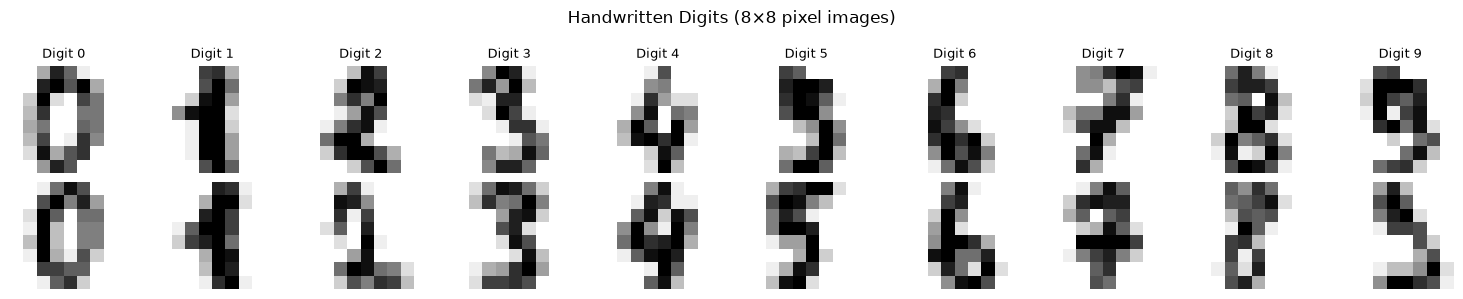

In [6]:
# Classic ML benchmark: recognize digits 0-9
digits = load_digits()
print(f"Dataset: {digits.data.shape[0]} images, {digits.data.shape[1]} pixels each")
print(f"Classes: {digits.target_names}")

# Show some digits
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(2):
    for j, cls in enumerate(range(10)):
        idx = np.where(digits.target == cls)[0][i]
        axes[i, j].imshow(digits.images[idx], cmap='gray_r')
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(f"Digit {cls}", fontsize=9)
plt.suptitle("Handwritten Digits (8×8 pixel images)", fontsize=12)
plt.tight_layout()
plt.savefig("/tmp/digits_sample.png", dpi=100)
plt.show()

KNN (k=5): Test Accuracy = 96.39%
SVM (RBF): Test Accuracy = 98.06%


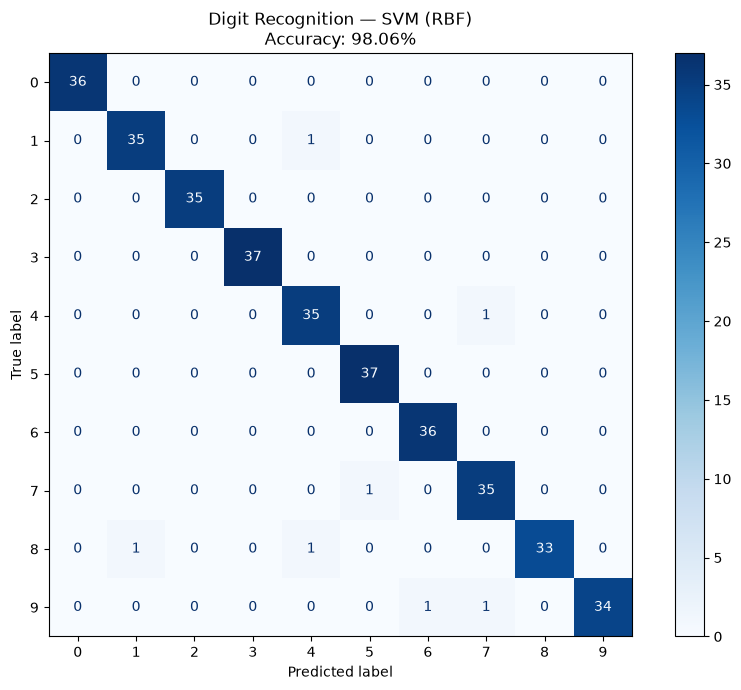

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

X_dig, y_dig = digits.data, digits.target
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(X_dig, y_dig, test_size=0.2, 
                                                     random_state=42, stratify=y_dig)
sc_d = StandardScaler()
X_tr_ds = sc_d.fit_transform(X_tr_d)
X_te_ds = sc_d.transform(X_te_d)

# Compare KNN and SVM
results = {}
for name, model in [("KNN (k=5)", KNeighborsClassifier(n_neighbors=5)),
                     ("SVM (RBF)", SVC(kernel='rbf', C=10, gamma='scale'))]:
    model.fit(X_tr_ds, y_tr_d)
    results[name] = {'model': model, 'acc': model.score(X_te_ds, y_te_d)}
    print(f"{name}: Test Accuracy = {results[name]['acc']:.2%}")

# Confusion Matrix for best model
best_name = max(results, key=lambda k: results[k]['acc'])
best_model = results[best_name]['model']
y_pred_d = best_model.predict(X_te_ds)

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(y_te_d, y_pred_d, ax=ax, cmap='Blues')
ax.set_title(f"Digit Recognition — {best_name}\nAccuracy: {results[best_name]['acc']:.2%}")
plt.tight_layout()
plt.savefig("/tmp/digits_confusion.png", dpi=100)
plt.show()

## Summary

| Algorithm | Best For | Key Param |
|---|---|---|
| KNN | Small datasets, non-linear | k (neighbors) |
| SVM Linear | Text, high-dim, linearly separable | C |
| SVM RBF | Most non-linear problems | C, gamma |

**Rules of thumb:**
- Always scale features before KNN and SVM
- KNN is slow at prediction for large datasets (calculates all distances)
- SVM is slow to train on large datasets but excellent accuracy

**Next notebook →** `11_Naive_Bayes.ipynb`